In [1]:
# (데이터 증강 + CNN 개선)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 1574 files belonging to 4 classes.
Using 1260 files for training.
Found 1574 files belonging to 4 classes.
Using 314 files for validation.


In [3]:
# 클래스 이름
class_names = train_ds.class_names

print("클래스 목록")
print(class_names)

클래스 목록
['can', 'paper', 'plastic', 'vinyl']


In [4]:
# 데이터 증강
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [7]:
def create_model():

    model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Feature Extractor로 사용
    model.trainable = False

    model = tf.keras.Sequential([

        data_augmentation,

        tf.keras.layers.Rescaling(1./127.5, offset=-1),

        model,

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            len(class_names),
            activation='softmax'
        )
    ])

    return model

In [9]:
model = create_model()

# 컴파일

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# 조기종료
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

In [11]:
# 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 783s 19s/step - accuracy: 0.5587 - loss: 1.0890 - val_accuracy: 0.7675 - val_loss: 0.5788
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.8056 - loss: 0.5105 - val_accuracy: 0.8535 - val_loss: 0.4056
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.8595 - loss: 0.3964 - val_accuracy: 0.8822 - val_loss: 0.3398
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8738 - loss: 0.3489 - val_accuracy: 0.8885 - val_loss: 0.3217
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.9040 - loss: 0.2884 - val_accuracy: 0.8949 - val_loss: 0.3006
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9056 - loss: 0.2714 - val_accuracy: 0.8981 - val_loss: 0.2851
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9175 - loss: 0.2401 - val_accuracy: 0.9045 - val_loss: 0.2811
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.9183 - loss: 0.2282 - val_accuracy: 0.9045 - 

In [12]:
# 평가
loss, acc = model.evaluate(val_ds)

print(f"Validation Accuracy : {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9204 - loss: 0.2592
Validation Accuracy : 0.9204


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

In [14]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[47  1  3  2]
 [ 2 88  3  3]
 [ 1  1 79  4]
 [ 3  2  0 75]]


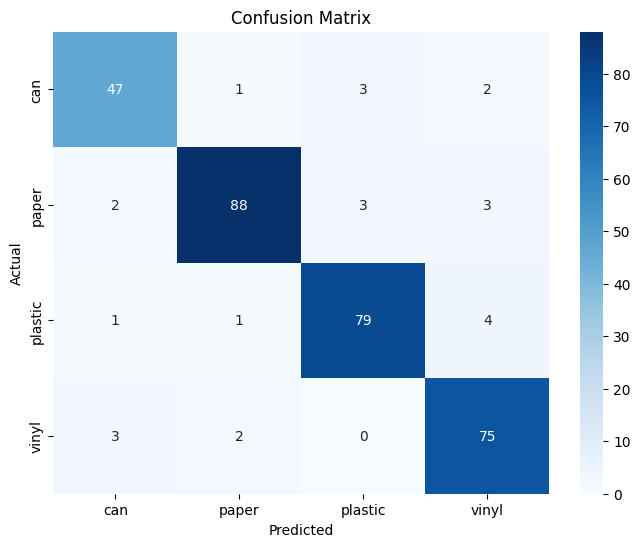

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
# 모델 저장
model.save(
    "/content/drive/MyDrive/OSS/AI/model/bset_model_v9.keras"
)

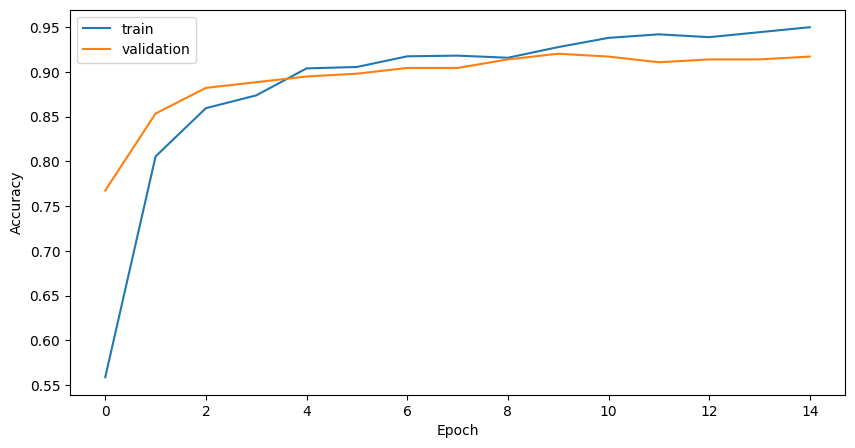

In [16]:
import matplotlib.pyplot as plt

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
print(history.history['val_loss'])
print(history.history['val_accuracy'])

[0.5787639021873474, 0.4055522382259369, 0.33975377678871155, 0.321719229221344, 0.30057018995285034, 0.2850511372089386, 0.28107038140296936, 0.2802821099758148, 0.26181384921073914, 0.2591620981693268, 0.26295650005340576, 0.2552747130393982, 0.2598089277744293, 0.2619260549545288, 0.23719817399978638]
[0.7675158977508545, 0.8535031676292419, 0.8821656107902527, 0.8885350227355957, 0.8949044346809387, 0.8980891704559326, 0.9044585824012756, 0.9044585824012756, 0.9140127301216125, 0.9203821420669556, 0.9171974658966064, 0.9108280539512634, 0.9140127301216125, 0.9140127301216125, 0.9171974658966064]


In [19]:
print(max(history.history['val_accuracy']))

0.9203821420669556
